In [1]:
#installing dependencies
!pip install -q transformers==4.40.0 torch torchvision pillow tqdm matplotlib faiss-cpu


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#importing libraries
import os
import math
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import faiss
import matplotlib.pyplot as plt

from transformers import CLIPProcessor, CLIPModel

In [ ]:
#configurations
DATA_DIR = os.path.abspath("archive (13)") if os.path.isdir("archive (13)") else os.path.abspath(".")
CLEANED_CSV_PATH = os.path.join(DATA_DIR, "cleaned_data.csv")
IMAGE_DIR = os.path.join(DATA_DIR, "images")
# Output paths
CLIP_EMBEDDINGS_PATH = os.path.join(DATA_DIR, "clip_image_embeddings.npy")
CLIP_INDEX_PATH = os.path.join(DATA_DIR, "clip_index.faiss")
# Batch size for embedding extraction
BATCH_SIZE = 64 # reduce to 32 or 16 if low VRAM
# Device selection
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Setup is completed!")
print("Using device:", DEVICE)

Setup is completed!
Using device: cpu


In [ ]:
#loading images and verifying dataset
df = pd.read_csv(CLEANED_CSV_PATH)
df["image_path"] = df["id"].astype(int).apply(lambda image_id: os.path.join(IMAGE_DIR, f"{image_id}.jpg"))
print("Data loaded successfully!")
print("Shape of dataset:", df.shape)

Data loaded successfully!
Shape of dataset: (44419, 12)


In [5]:
display(df.head(10))

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,exists
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,C:\Users\okkk\Desktop\DSA project\archive (13)...,True
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,C:\Users\okkk\Desktop\DSA project\archive (13)...,True
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,C:\Users\okkk\Desktop\DSA project\archive (13)...,True
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,C:\Users\okkk\Desktop\DSA project\archive (13)...,True
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,C:\Users\okkk\Desktop\DSA project\archive (13)...,True
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt,C:\Users\okkk\Desktop\DSA project\archive (13)...,True
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,Fabindia Men Striped Green Shirt,C:\Users\okkk\Desktop\DSA project\archive (13)...,True
7,26960,Women,Apparel,Topwear,Shirts,Purple,Summer,2012.0,Casual,Jealous 21 Women Purple Shirt,C:\Users\okkk\Desktop\DSA project\archive (13)...,True
8,29114,Men,Accessories,Socks,Socks,Navy Blue,Summer,2012.0,Casual,Puma Men Pack of 3 Socks,C:\Users\okkk\Desktop\DSA project\archive (13)...,True
9,30039,Men,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,Skagen Men Black Watch,C:\Users\okkk\Desktop\DSA project\archive (13)...,True


In [6]:
df["exists"] = df["image_path"].apply(os.path.exists)
missing = df[df["exists"] == False]
print(f"Missing images: {len(missing)}")

Missing images: 0


In [7]:
df = df[df["exists"] == True].reset_index(drop=True)
print("Final dataset size:", df.shape)

Final dataset size: (44419, 12)


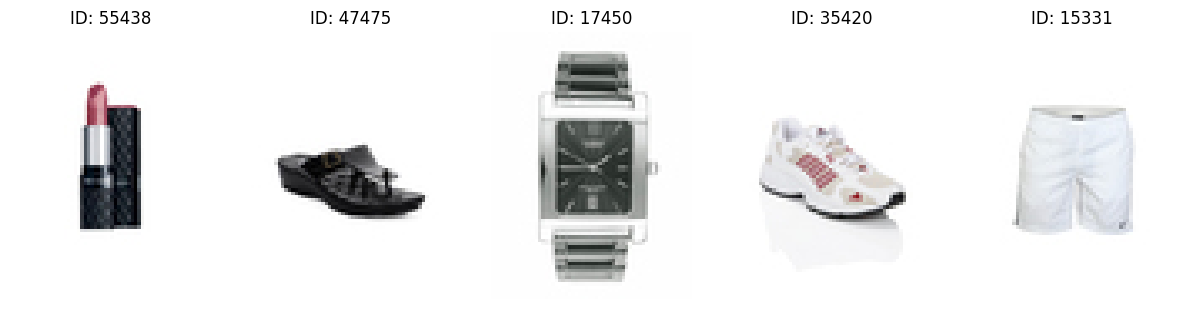

In [8]:
#retriving few sample images
import random
from PIL import Image
import matplotlib.pyplot as plt
sample_indices = random.sample(range(len(df)), 5)
plt.figure(figsize=(15, 8))
for i, idx in enumerate(sample_indices):
    img_path = df.loc[idx, "image_path"]
    plt.subplot(1, 5, i+1)
    plt.imshow(Image.open(img_path))
    plt.title(f"ID: {df.loc[idx, 'id']}")
    plt.axis("off")
plt.show()

In [9]:
#Loading CLIP model
from transformers import CLIPProcessor, CLIPModel
# Load pretrained CLIP model and processor
print("Loading CLIP model...")
model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name)
clip_processor = CLIPProcessor.from_pretrained(model_name)

Loading CLIP model...


C:\Users\okkk\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\okkk\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [10]:
# Send to device (CPU or GPU)
clip_model.to(DEVICE)
clip_model.eval()  # inference mode
print("CLIP model loaded successfully!")
print(f"Model device: {DEVICE}")

CLIP model loaded successfully!
Model device: cpu


In [14]:
# Function to extract embeddings in batches
def extract_clip_image_embeddings(df, batch_size=BATCH_SIZE):
    all_features = []    
    for i in tqdm(range(0, len(df), batch_size), desc="Extracting CLIP embeddings"):
        batch_paths = df["image_path"].iloc[i:i+batch_size].tolist()
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        # Preprocess and move to device
        inputs = clip_processor(images=images, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            features = clip_model.get_image_features(**inputs)
        # Normalize features
        features = features / features.norm(dim=-1, keepdim=True)
        all_features.append(features.cpu().numpy())
        # Optional progress log
        if i % (batch_size * 10) == 0:
            print(f"Processed {i}/{len(df)} images")
    # Combine all batches into a single array
    all_features = np.vstack(all_features)
    return all_features
# Run embedding extraction
print("Extracting embeddings for all images...")
clip_image_embeddings = extract_clip_image_embeddings(df, batch_size=BATCH_SIZE)
# Save to disk
np.save(CLIP_EMBEDDINGS_PATH, clip_image_embeddings)
print("Embeddings extraction complete!")
print("Saved to:", CLIP_EMBEDDINGS_PATH)
print("Embeddings shape:", clip_image_embeddings.shape)


Extracting embeddings for all images...


Extracting CLIP embeddings:   0%|                                                    | 1/695 [00:07<1:22:27,  7.13s/it]

Processed 0/44419 images


Extracting CLIP embeddings:   2%|▊                                                  | 11/695 [01:25<1:21:46,  7.17s/it]

Processed 640/44419 images


...

Processed 43520/44419 images


Extracting CLIP embeddings:  99%|█████████████████████████████████████████████████▋| 691/695 [1:40:08<00:40, 10.22s/it]

Processed 44160/44419 images


Extracting CLIP embeddings: 100%|██████████████████████████████████████████████████| 695/695 [1:40:38<00:00,  8.69s/it]


Embeddings extraction complete!
Saved to: C:\Users\okkk\Desktop\DSA project\archive (13)\clip_image_embeddings.npy
Embeddings shape: (44419, 512)


In [11]:
#Build FAISS Index for Fast Search
# Load embeddings 
embeddings = np.load(CLIP_EMBEDDINGS_PATH).astype("float32")
# Normalize embeddings 
faiss.normalize_L2(embeddings)
# Build FAISS index 
d = embeddings.shape[1]
index = faiss.IndexFlatIP(d)
index.add(embeddings)
print("FAISS index built successfully!")
print("Total images indexed:", index.ntotal)
# Save index for reuse
faiss.write_index(index, CLIP_INDEX_PATH)
print("FAISS index saved to:", CLIP_INDEX_PATH)


FAISS index built successfully!
Total images indexed: 44419
FAISS index saved to: C:\Users\okkk\Desktop\DSA project\archive (13)\clip_index.faiss


In [13]:
#Interactive Text → Image Search
from ipywidgets import widgets, interact
from IPython.display import display
def search_by_text(query, top_k=20):
    text_inputs = clip_processor(text=[query], return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        text_features = clip_model.get_text_features(**text_inputs)

    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    text_vector = text_features.cpu().numpy().astype("float32")

    distances, indices = index.search(text_vector, top_k)
    return indices[0], distances[0]
def show_search_results(query, indices):
    num_images = len(indices)
    per_row = 5
    rows = math.ceil(num_images / per_row)

    plt.figure(figsize=(20, rows * 4))
    plt.suptitle(f"Query: {query}", fontsize=16, y=1.02)

    for i, idx in enumerate(indices):
        img_path = df.iloc[idx]["image_path"]
        plt.subplot(rows, per_row, i + 1)
        plt.imshow(Image.open(img_path))
        plt.title(f"#{i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
#Interactive Widget
query_box = widgets.Text(
    value='red floral dress',
    placeholder='Type your fashion query here...',
    description='Search:',
    disabled=False,
    layout=widgets.Layout(width='60%')
)

search_button = widgets.Button(
    description="🔍 Search",
    button_style='success',
    tooltip="Click to search similar fashion images"
)

output = widgets.Output()

def on_search_click(b):
    output.clear_output()
    with output:
        query = query_box.value
        indices, _ = search_by_text(query, top_k=20)
        show_search_results(query, indices)

search_button.on_click(on_search_click)

display(query_box, search_button, output)


Text(value='red floral dress', description='Search:', layout=Layout(width='60%'), placeholder='Type your fashi…

Button(button_style='success', description='🔍 Search', style=ButtonStyle(), tooltip='Click to search similar f…

Output()

In [17]:
import os
print(os.getcwd())


C:\Users\okkk


In [ ]:
import os
# Change working directory to the project data folder
os.chdir(DATA_DIR)
# Confirm it worked
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\okkk\Desktop\DSA project\archive (13)
